# Model Evaluation for Classification

| Learning Curve                                                  | Validation Curve                                                                  |
| --------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| Performance changes with training data size                     | Performance changes with hyperparameter values                                    |
| Checks model performance as data size increases                 | Checks effect of model complexity or regularization through hyperparameter tuning |
| Diagnoses underfitting vs. overfitting related to training size | Focuses on hyperparameter tuning and optimization                                 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="liblinear", penalty="l2", random_state=1),
)

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
print("Score: %.3f" % pipe_lr.score(X_test, y_test))

Score: 0.965


# Evaluating Models Using a Learning Curve

## What is a Learning Curve?

A **learning curve** is a graph that shows how a machine learning model's performance changes as the size of the training dataset increases.

Why Use Learning Curves?

- **Diagnose Underfitting**  
  Both training and validation scores are low → model is too simple to capture the data patterns.

- **Diagnose Overfitting**  
  Training score is high but validation score is low → model fits the training data too closely and does not generalize well.

- **Assess Benefit of More Data**  
  If validation score improves as training size grows, adding more data can help improve performance.

- **Find Appropriate Model Complexity**  
  Helps decide if the model complexity is suitable given the amount of data.


How Does the `learning_curve` Function Work?

- Trains the model on different sized subsets of the training data.
- Returns training and validation scores for each subset size.
- Enables visualization of model learning behavior over increasing training sizes.

Summary

A learning curve helps answer:

> "Is my model learning well with the current amount of data?"  
> "Will adding more training data improve performance?"

It’s a powerful diagnostic tool to understand model fit and data sufficiency.

## Hands on!
* Use the `learning_curve` function.
* We aim to assess how the number of training samples affects model performance.


In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe_lr,  # pipeline with logistic regression
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=10,  # cross-validation
    n_jobs=1,  # concurrent jobs, -1 means using all processors
)

In [15]:
train_means = np.mean(train_scores, axis=1).round(3)
test_means = np.mean(test_scores, axis=1).round(3)
print("Train scores:\n", train_means)
print("\nTest scores:\n", test_means)

Train scores:
 [1.    0.987 0.992 0.994 0.995 0.991 0.993 0.99  0.99  0.992]

Test scores:
 [0.952 0.957 0.96  0.962 0.98  0.98  0.985 0.985 0.98  0.982]


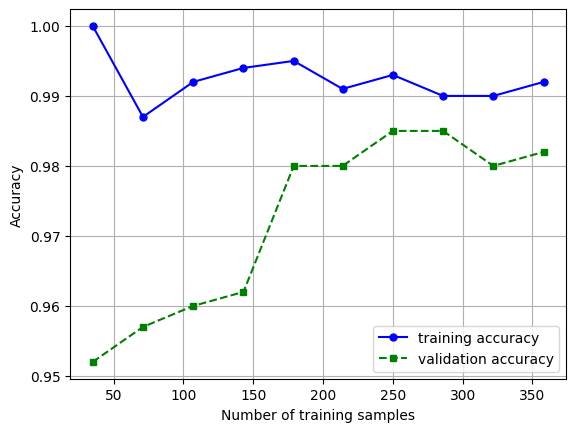

In [20]:
plt.plot(
    train_sizes,
    train_means,
    color="blue",
    marker="o",
    markersize=5,
    label="training accuracy",
)

plt.plot(
    train_sizes,
    test_means,
    color="green",
    linestyle="--",
    marker="s",
    markersize=5,
    label="validation accuracy",
)
plt.xlabel("Number of training samples")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid()
plt.show()

* The `train_sizes` parameter is used to generate 10 different proportions of the training set, ranging from 0.1 to 1.0.
* Use the `cv` parameter to apply 10-fold cross-validation.
* Visualize both training accuracy and validation accuracy(=test accuracy).
* The model performs well when the training data ratio is above 0.7 (approximately 250 samples).



# Evaluating Models Using a Validation Curve

## What is a Validation Curve? Why Use it?


A **validation curve** is a graph that shows how a machine learning model's performance changes as a specific hyperparameter value varies.

- **Tune Hyperparameters**  
  Helps identify the best value or range for a model hyperparameter by showing its effect on training and validation scores.

- **Diagnose Underfitting and Overfitting**  
  - If both training and validation scores are low at certain parameter values → underfitting.  
  - If training score is high but validation score is low at certain values → overfitting.

- **Understand Model Sensitivity**  
  Reveals how sensitive the model's performance is to changes in the hyperparameter.


How Does the `validation_curve` Function Work?

- Trains the model multiple times, each with a different value of the chosen hyperparameter.
- Returns training and validation scores for each hyperparameter value.
- Enables visualization of how model performance varies with the hyperparameter.

Summary

A validation curve helps answer:

> "What is the optimal value of this hyperparameter?"  
> "How does changing this parameter affect underfitting or overfitting?"

It is an essential tool for hyperparameter tuning and model optimization.

## Hands on!


* We evaluate how changes in certain hyperparameters affect model performance.
* Use the `validation_curve` function:
    * `param_name`: The name of the hyperparameter to be changed.
    * `param_range`: The range of values to use for the hyperparameter.


In [26]:
from sklearn.model_selection import validation_curve

train_scores, test_scores = validation_curve(
    estimator=pipe_lr,
    X=X_train,
    y=y_train,
    param_name="logisticregression__C",  # Regularization parameter
    param_range=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  # C values
    cv=10,
)

In [27]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

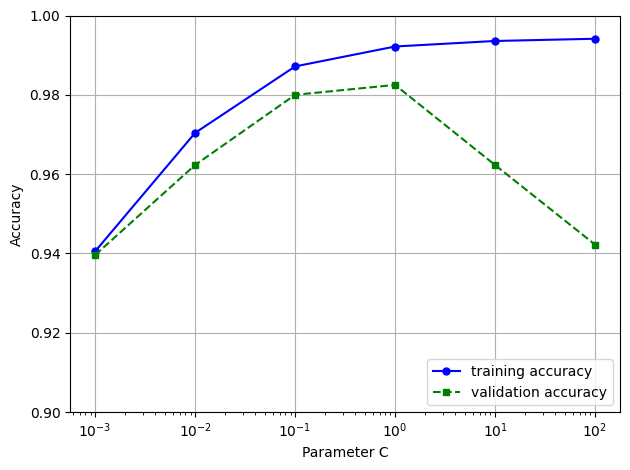

In [29]:
plt.plot(
    [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    train_mean,
    color="blue",
    marker="o",
    markersize=5,
    label="training accuracy",
)
plt.plot(
    [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    test_mean,
    color="green",
    linestyle="--",
    marker="s",
    markersize=5,
    label="validation accuracy",
)
plt.grid()
plt.xscale("log")
plt.legend(loc="lower right")
plt.xlabel("Parameter C")
plt.ylabel("Accuracy")
plt.ylim([0.9, 1.00])
plt.tight_layout()
plt.show()

* The `validation_curve` function estimates model performance using cross-validation by default.
* You specify the hyperparameter to evaluate within the function.
* Example: `param_name='logisticregression__C'` — this refers to the `C` parameter of the Logistic Regression model.
* Increasing the value of `C` reduces regularization, which may lead to slight overfitting.
* In this case, the optimal values appear to be `0.01` or `0.1`.